# H4: H₂S Presence as a Proxy for Sulfate-Reducing Environments

## Hypotheses

**H0 (null):** Waters with detected H₂S show no systematic difference in SO₄/Cl or HCO₃/Cl ratios compared to waters without H₂S.

**H1 (alternative):** H₂S-positive produced waters show significantly **lower SO₄/Cl** and **higher HCO₃/Cl** ratios than H₂S-absent waters at equivalent salinity, consistent with sulfate reduction as an active or historical geochemical process.

---

## Scientific Background

### Bacterial Sulfate Reduction (BSR)

Sulfate-reducing bacteria (SRB) couple the oxidation of organic matter to the reduction of sulfate as the terminal electron acceptor:

$$\text{SO}_4^{2-} + 2\text{CH}_2\text{O} \rightarrow \text{H}_2\text{S} + 2\text{HCO}_3^-$$

This reaction has two key geochemical signatures:
1. **SO₄ depletion** — sulfate is consumed, reducing the SO₄/Cl ratio (Cl is conservative and used as a salinity reference).
2. **HCO₃ enrichment** — bicarbonate is produced, raising the HCO₃/Cl ratio.

BSR occurs at temperatures generally below ~80°C and is dominant in near-surface and shallow subsurface environments where organic carbon is available.

### Thermochemical Sulfate Reduction (TSR)

At temperatures above ~100–120°C, sulfate can be abiotically reduced by hydrocarbons:

$$\text{SO}_4^{2-} + \text{CH}_4 \rightarrow \text{H}_2\text{S} + \text{CO}_2 + 2\text{H}_2\text{O}$$

TSR also depletes SO₄, but the CO₂ product may drive carbonate precipitation rather than HCO₃ enrichment. Deep wells (DEPTHWELL > 3000 m) are more likely candidates for TSR. **Both BSR and TSR deplete SO₄**, so H₂S presence is a proxy for *sulfate reduction generally*, not exclusively microbial activity.

### Rationale for Ion Ratios

Produced waters span orders of magnitude in salinity (TDS ~1,000–350,000 mg/L). Using **molar ratios relative to Cl⁻** (a conservative, non-reactive tracer) normalises for evaporative concentration and mixing, isolating the *reactive* geochemical signal.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import os, sys
sys.path.insert(0, '/home/gazimahmud/BERIL-research-observatory')

from berdl_notebook_utils.setup_spark_session import get_spark_session
spark = get_spark_session()

FIGURES_DIR = '/home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Spark session ready.')
print(f'Figures will be saved to: {FIGURES_DIR}')

Spark session ready.
Figures will be saved to: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures


In [2]:
df = spark.sql("""
    SELECT 
        H2S,
        TRY_CAST(SO4 AS DOUBLE) as SO4,
        TRY_CAST(HCO3 AS DOUBLE) as HCO3,
        TRY_CAST(Cl AS DOUBLE) as Cl,
        TRY_CAST(Ca AS DOUBLE) as Ca,
        TRY_CAST(Na AS DOUBLE) as Na,
        TRY_CAST(Mg AS DOUBLE) as Mg,
        TDSUSGS, BASIN, WELLTYPE, DEPTHWELL
    FROM u_gazimahmud__mydb.usgs_pw
    WHERE H2S IS NOT NULL
      AND TRY_CAST(SO4 AS DOUBLE) IS NOT NULL AND TRY_CAST(Cl AS DOUBLE) IS NOT NULL
      AND TRY_CAST(HCO3 AS DOUBLE) IS NOT NULL
      AND TRY_CAST(Cl AS DOUBLE) > 0
""").toPandas()

# Parse H2S: it may be numeric string or presence/absence
# Check what values it takes
print("H2S value sample:")
print(df['H2S'].value_counts().head(20))
print(f"\nTotal rows loaded: {len(df):,}")
print(f"\nNumeric columns summary:")
print(df[['SO4', 'HCO3', 'Cl', 'Ca', 'Na', 'Mg']].describe())

H2S value sample:
H2S
<MDL    18638
<PQL     6217
2         207
0.5       197
1         195
3         118
1.5       115
4          71
2.5        44
5          32
0.3        30
0.35       30
0.25       26
0.4        25
6          23
0.2        23
7          17
10         17
0.45       17
3.5        16
Name: count, dtype: int64

Total rows loaded: 27,480

Numeric columns summary:
                SO4          HCO3             Cl            Ca             Na  \
count  27480.000000  27480.000000   27480.000000   27357.00000   24082.000000   
mean    1312.206668    814.548753   61754.400426    5813.26166   32978.132102   
std     1757.417651   1416.222915   68727.881540   10032.80805   35854.356422   
min        0.010000      0.201000       0.250000       0.80000       2.000000   
25%      133.000000    210.000000    6510.702500     284.00000    4254.250000   
50%      663.725000    451.000000   28633.765000    1650.00000   15219.055000   
75%     1876.700000    988.000000  108000.000000    

In [3]:
# H2S may be a numeric concentration or X/absent
# Try to cast to numeric; treat >0 as present, =0 or non-numeric as absent
df['H2S_numeric'] = pd.to_numeric(df['H2S'], errors='coerce')
print(f"H2S as numeric: {df['H2S_numeric'].notna().sum():,} parseable, "
      f"{df['H2S_numeric'].isna().sum():,} non-numeric")

# Check for string presence markers in the non-numeric rows
non_numeric_vals = df.loc[df['H2S_numeric'].isna(), 'H2S'].value_counts().head(20)
print("\nNon-numeric H2S values:")
print(non_numeric_vals)

# Classify: positive numeric value OR known presence strings
df['H2S_present'] = (
    (df['H2S_numeric'] > 0) |
    (df['H2S'].str.strip().str.lower().isin(['x', 'present', 'yes', 'detected', 'trace']))
).fillna(False)

n_present = df['H2S_present'].sum()
n_absent  = (~df['H2S_present']).sum()
print(f"\nH2S present : {n_present:,} ({100*n_present/len(df):.1f}%)")
print(f"H2S absent  : {n_absent:,} ({100*n_absent/len(df):.1f}%)")

# Compute ion ratios in meq/L
# Equivalent weights: SO4²⁻ = 96.06/2 = 48.03, HCO3⁻ = 61.02, Cl⁻ = 35.45
df['SO4_meq']  = df['SO4']  / 48.03
df['HCO3_meq'] = df['HCO3'] / 61.02
df['Cl_meq']   = df['Cl']   / 35.45

df['SO4_Cl']  = df['SO4_meq']  / df['Cl_meq']
df['HCO3_Cl'] = df['HCO3_meq'] / df['Cl_meq']

# Filter outliers (keep ratios in 0.0001–100 range)
n_before = len(df)
df = df[(df['SO4_Cl']  > 0)    & (df['SO4_Cl']  < 100)].copy()
df = df[(df['HCO3_Cl'] > 0)    & (df['HCO3_Cl'] < 100)].copy()
print(f"\nAfter ratio filtering: {len(df):,}  (removed {n_before - len(df):,} outliers)")

# Log10 ratios for plotting
df['log_SO4_Cl']  = np.log10(df['SO4_Cl'])
df['log_HCO3_Cl'] = np.log10(df['HCO3_Cl'])

# Convenience label
df['H2S_label'] = df['H2S_present'].map({True: 'H₂S Present', False: 'H₂S Absent'})

grp_present = df[df['H2S_present']]
grp_absent  = df[~df['H2S_present']]
print(f"\nFinal group sizes — present: {len(grp_present):,}, absent: {len(grp_absent):,}")

H2S as numeric: 2,603 parseable, 24,877 non-numeric

Non-numeric H2S values:
H2S
<MDL     18638
<PQL      6217
UNK          7
<0.4         7
<0.1         7
<0.01        1
Name: count, dtype: int64

H2S present : 2,603 (9.5%)
H2S absent  : 24,877 (90.5%)

After ratio filtering: 27,385  (removed 95 outliers)

Final group sizes — present: 2,553, absent: 24,832


## 1. SO₄/Cl Ratio: H₂S Present vs Absent

If sulfate reduction has occurred, H₂S-positive samples should show systematically **lower** SO₄/Cl ratios compared to H₂S-absent samples.  
We plot log₁₀(SO₄/Cl) as a violin + box chart and test the difference with the non-parametric Mann-Whitney U test (appropriate given the heavily skewed, non-normal distributions typical of produced-water geochemistry).

Mann-Whitney U = 31267620, p = 0.2578, rank-biserial r = 0.014
Interpretation: r > 0 means H2S-present has LOWER SO4/Cl than H2S-absent


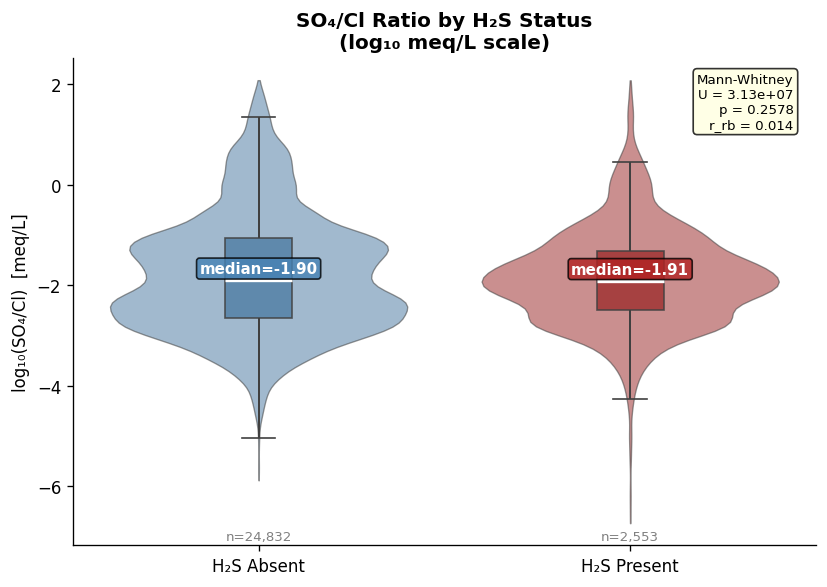

Saved: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures/h4_so4cl_by_h2s.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

palette = {'H₂S Absent': 'steelblue', 'H₂S Present': 'firebrick'}
order   = ['H₂S Absent', 'H₂S Present']

# Violin
sns.violinplot(
    data=df, x='H2S_label', y='log_SO4_Cl',
    order=order, palette=palette,
    inner=None, cut=0.5, linewidth=0.8, alpha=0.55, ax=ax
)
# Box overlay
sns.boxplot(
    data=df, x='H2S_label', y='log_SO4_Cl',
    order=order, palette=palette,
    width=0.18, showcaps=True, fliersize=0,
    boxprops=dict(alpha=0.85), medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2), ax=ax
)

# Annotate medians and sample sizes
for i, label in enumerate(order):
    grp = df[df['H2S_label'] == label]['log_SO4_Cl']
    med = grp.median()
    ax.text(i, med + 0.08, f'median={med:.2f}', ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=list(palette.values())[i], alpha=0.8))
    ax.text(i, ax.get_ylim()[0] + 0.05, f'n={len(grp):,}', ha='center', va='bottom',
            fontsize=8, color='grey')

# Mann-Whitney U test
u_stat, p_val = stats.mannwhitneyu(
    grp_present['log_SO4_Cl'].dropna(),
    grp_absent['log_SO4_Cl'].dropna(),
    alternative='two-sided'
)
# Rank-biserial correlation as effect size
n1 = len(grp_present['log_SO4_Cl'].dropna())
n2 = len(grp_absent['log_SO4_Cl'].dropna())
r_rb = 1 - (2 * u_stat) / (n1 * n2)  # positive => present < absent
p_str = f'p < 0.001' if p_val < 0.001 else f'p = {p_val:.4f}'
print(f"Mann-Whitney U = {u_stat:.0f}, {p_str}, rank-biserial r = {r_rb:.3f}")
print(f"Interpretation: r > 0 means H2S-present has LOWER SO4/Cl than H2S-absent")

ax.set_title('SO₄/Cl Ratio by H₂S Status\n(log₁₀ meq/L scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('log₁₀(SO₄/Cl)  [meq/L]', fontsize=10)
ax.text(0.97, 0.97,
        f'Mann-Whitney\nU = {u_stat:.2e}\n{p_str}\nr_rb = {r_rb:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
sns.despine()
fig.tight_layout()
out_path = f'{FIGURES_DIR}/h4_so4cl_by_h2s.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 2. HCO₃/Cl Ratio: H₂S Present vs Absent

The BSR reaction produces bicarbonate (HCO₃⁻) stoichiometrically alongside H₂S.  
H₂S-positive waters should therefore show **higher** HCO₃/Cl ratios.  
Note that carbonate equilibria (e.g., CO₂ degassing, calcite precipitation) can partially obscure this signal, but a systematic enrichment is still expected.

Mann-Whitney U = 42286152, p < 0.001, rank-biserial r = -0.334
Interpretation: r < 0 means H2S-present has HIGHER HCO3/Cl than H2S-absent


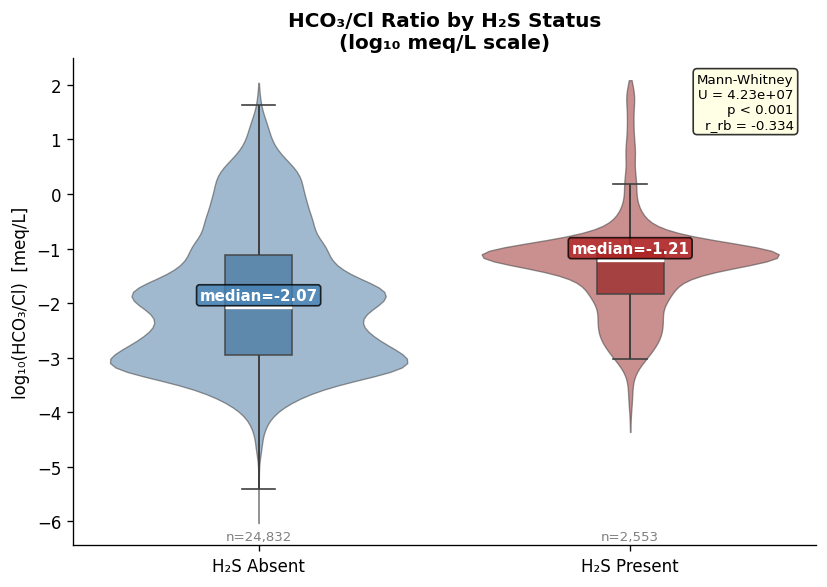

Saved: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures/h4_hco3cl_by_h2s.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

# Violin
sns.violinplot(
    data=df, x='H2S_label', y='log_HCO3_Cl',
    order=order, palette=palette,
    inner=None, cut=0.5, linewidth=0.8, alpha=0.55, ax=ax
)
# Box overlay
sns.boxplot(
    data=df, x='H2S_label', y='log_HCO3_Cl',
    order=order, palette=palette,
    width=0.18, showcaps=True, fliersize=0,
    boxprops=dict(alpha=0.85), medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.2), ax=ax
)

# Annotate medians and sample sizes
for i, label in enumerate(order):
    grp = df[df['H2S_label'] == label]['log_HCO3_Cl']
    med = grp.median()
    ax.text(i, med + 0.08, f'median={med:.2f}', ha='center', va='bottom',
            fontsize=9, color='white', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=list(palette.values())[i], alpha=0.8))
    ax.text(i, ax.get_ylim()[0] + 0.05, f'n={len(grp):,}', ha='center', va='bottom',
            fontsize=8, color='grey')

# Mann-Whitney U test
u_stat_h, p_val_h = stats.mannwhitneyu(
    grp_present['log_HCO3_Cl'].dropna(),
    grp_absent['log_HCO3_Cl'].dropna(),
    alternative='two-sided'
)
n1h = len(grp_present['log_HCO3_Cl'].dropna())
n2h = len(grp_absent['log_HCO3_Cl'].dropna())
r_rb_h = 1 - (2 * u_stat_h) / (n1h * n2h)
p_str_h = f'p < 0.001' if p_val_h < 0.001 else f'p = {p_val_h:.4f}'
print(f"Mann-Whitney U = {u_stat_h:.0f}, {p_str_h}, rank-biserial r = {r_rb_h:.3f}")
print(f"Interpretation: r < 0 means H2S-present has HIGHER HCO3/Cl than H2S-absent")

ax.set_title('HCO₃/Cl Ratio by H₂S Status\n(log₁₀ meq/L scale)', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('log₁₀(HCO₃/Cl)  [meq/L]', fontsize=10)
ax.text(0.97, 0.97,
        f'Mann-Whitney\nU = {u_stat_h:.2e}\n{p_str_h}\nr_rb = {r_rb_h:.3f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
sns.despine()
fig.tight_layout()
out_path = f'{FIGURES_DIR}/h4_hco3cl_by_h2s.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 3. Joint SO₄ Depletion and HCO₃ Enrichment

The BSR reaction predicts a specific **bivariate signature**: simultaneously low SO₄/Cl and high HCO₃/Cl.  
We visualise this jointly in a scatter plot, partitioned into quadrants defined by the median ratios of the H₂S-absent group (the geochemical baseline).  

**Expected BSR quadrant:** lower-left for SO₄/Cl AND upper for HCO₃/Cl — i.e., the **bottom-right quadrant** (high HCO₃/Cl, low SO₄/Cl).


Quadrant counts (based on H2S-absent medians):
Group            LowSO4/HighHCO3  HighSO4/HighHCO3   LowSO4/LowHCO3  HighSO4/LowHCO3
H₂S Absent          3351 (13%)       9065 (37%)       9065 (37%)       3351 (13%)
H₂S Present         1108 (43%)        960 (38%)        179 (7%)        306 (12%)


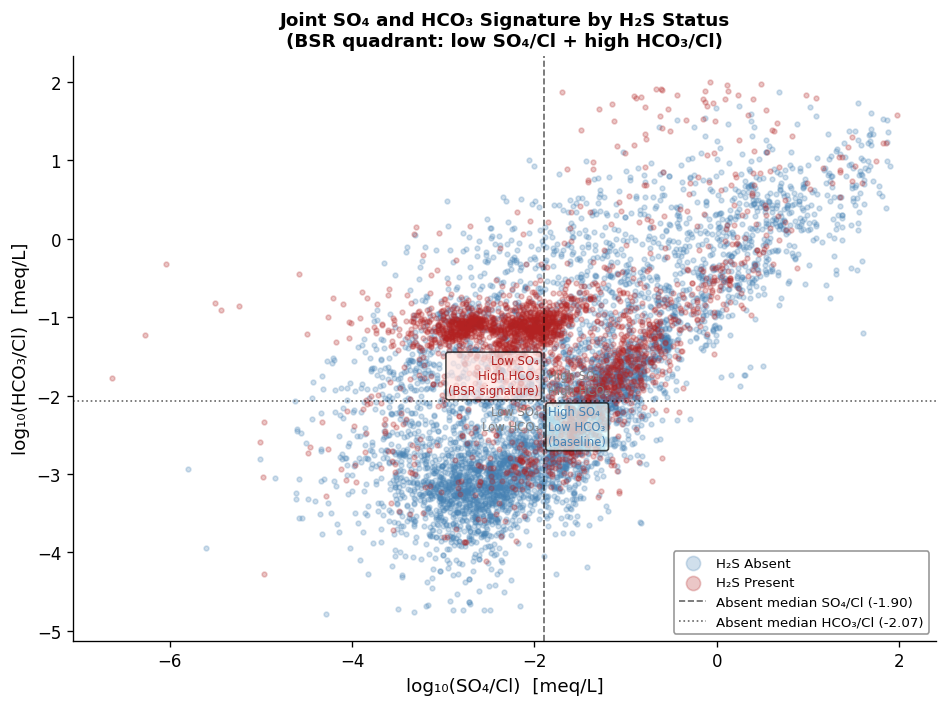


Saved: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures/h4_so4_hco3_scatter.png


In [6]:
# Subsample for readability (up to 5000 points per group)
np.random.seed(42)
MAX_PTS = 5000
plot_absent  = grp_absent.sample(min(MAX_PTS, len(grp_absent)))
plot_present = grp_present.sample(min(MAX_PTS, len(grp_present)))
plot_df = pd.concat([plot_absent, plot_present])

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'H₂S Absent': 'steelblue', 'H₂S Present': 'firebrick'}
for label, grp_plot in plot_df.groupby('H2S_label'):
    ax.scatter(
        grp_plot['log_SO4_Cl'], grp_plot['log_HCO3_Cl'],
        c=colors[label], alpha=0.25, s=8, label=label, rasterized=True
    )

# Quadrant lines at medians of H2S-absent group
ref_so4_cl  = grp_absent['log_SO4_Cl'].median()
ref_hco3_cl = grp_absent['log_HCO3_Cl'].median()
ax.axvline(ref_so4_cl,  color='k', linestyle='--', linewidth=1.0, alpha=0.6,
           label=f'Absent median SO₄/Cl ({ref_so4_cl:.2f})')
ax.axhline(ref_hco3_cl, color='k', linestyle=':',  linewidth=1.0, alpha=0.6,
           label=f'Absent median HCO₃/Cl ({ref_hco3_cl:.2f})')

# Label quadrants
xlim = ax.get_xlim(); ylim = ax.get_ylim()
ax.text(ref_so4_cl - 0.05, ref_hco3_cl + 0.05, 'Low SO₄\nHigh HCO₃\n(BSR signature)',
        ha='right', va='bottom', fontsize=7, color='firebrick',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='mistyrose', alpha=0.7))
ax.text(ref_so4_cl + 0.05, ref_hco3_cl + 0.05, 'High SO₄\nHigh HCO₃',
        ha='left', va='bottom', fontsize=7, color='grey')
ax.text(ref_so4_cl - 0.05, ref_hco3_cl - 0.05, 'Low SO₄\nLow HCO₃',
        ha='right', va='top', fontsize=7, color='grey')
ax.text(ref_so4_cl + 0.05, ref_hco3_cl - 0.05, 'High SO₄\nLow HCO₃\n(baseline)',
        ha='left', va='top', fontsize=7, color='steelblue',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='lightcyan', alpha=0.7))

ax.set_xlabel('log₁₀(SO₄/Cl)  [meq/L]', fontsize=11)
ax.set_ylabel('log₁₀(HCO₃/Cl)  [meq/L]', fontsize=11)
ax.set_title('Joint SO₄ and HCO₃ Signature by H₂S Status\n(BSR quadrant: low SO₄/Cl + high HCO₃/Cl)',
             fontsize=11, fontweight='bold')
leg = ax.legend(loc='lower right', fontsize=8, markerscale=3,
                framealpha=0.8, edgecolor='grey')

# Quadrant counts
print("\nQuadrant counts (based on H2S-absent medians):")
print(f"{'Group':<15} {'LowSO4/HighHCO3':>16} {'HighSO4/HighHCO3':>17} {'LowSO4/LowHCO3':>16} {'HighSO4/LowHCO3':>16}")
for label, grp_q in df.groupby('H2S_label'):
    q_bsr   = ((grp_q['log_SO4_Cl'] < ref_so4_cl)  & (grp_q['log_HCO3_Cl'] >= ref_hco3_cl)).sum()
    q_hihi  = ((grp_q['log_SO4_Cl'] >= ref_so4_cl) & (grp_q['log_HCO3_Cl'] >= ref_hco3_cl)).sum()
    q_lolo  = ((grp_q['log_SO4_Cl'] < ref_so4_cl)  & (grp_q['log_HCO3_Cl'] < ref_hco3_cl)).sum()
    q_hilo  = ((grp_q['log_SO4_Cl'] >= ref_so4_cl) & (grp_q['log_HCO3_Cl'] < ref_hco3_cl)).sum()
    total   = len(grp_q)
    print(f"{label:<15} {q_bsr:>8} ({100*q_bsr/total:.0f}%)   "
          f"{q_hihi:>8} ({100*q_hihi/total:.0f}%)   "
          f"{q_lolo:>8} ({100*q_lolo/total:.0f}%)   "
          f"{q_hilo:>8} ({100*q_hilo/total:.0f}%)")

sns.despine()
fig.tight_layout()
out_path = f'{FIGURES_DIR}/h4_so4_hco3_scatter.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved: {out_path}')

## 4. Controlling for TDS (Salinity)

A potential confound is salinity: more saline (higher TDS) brines tend to have lower SO₄/Cl regardless of microbial activity, due to selective evaporite dissolution or deep brine evolution. We partition the dataset into four TDS bins and re-test the SO₄/Cl difference within each bin.

| TDS Bin | Label | Approximate water type |
|---------|-------|------------------------|
| < 10,000 mg/L | Freshwater–brackish | Shallow groundwater |
| 10,000–50,000 mg/L | Saline | Mixed/transitional |
| 50,000–150,000 mg/L | Brine | Deep formation water |
| > 150,000 mg/L | Hypersaline brine | Very deep / evaporite-influenced |

If BSR is the driver, the SO₄/Cl difference should persist across TDS bins.

Sample counts per TDS bin and H2S status:
H2S_label  H₂S Absent  H₂S Present
TDS_bin                           
<10K             4635          595
10K–50K          6886         1358
50K–150K         5434          359
>150K            7661          240

Mann-Whitney U test for SO₄/Cl (present vs absent) per TDS bin:
TDS Bin       n_present   n_absent            U      p-value     r_rb    Direction
<10K                595      4,635       703185       <0.001    0.490 present<absent
10K–50K           1,358      6,886      3398077       <0.001    0.273 present<absent
50K–150K            359      5,434      1280742       <0.001   -0.313 present>absent
>150K               240      7,661      1411618       <0.001   -0.536 present>absent


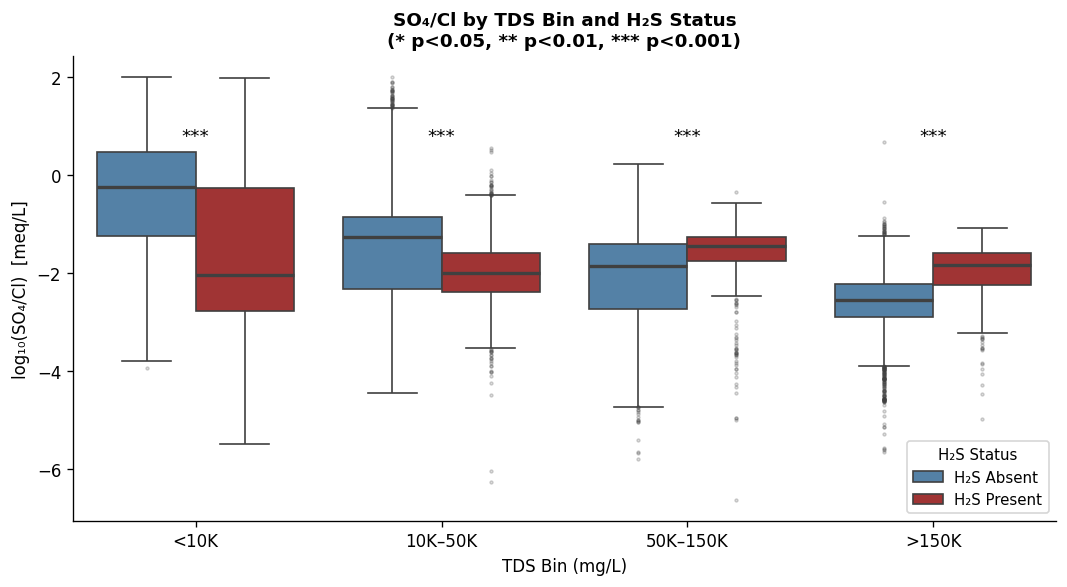

Saved: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures/h4_so4cl_by_tds_h2s.png


In [7]:
# TDS bins
tds_col = 'TDSUSGS'
df[tds_col] = pd.to_numeric(df[tds_col], errors='coerce')

tds_bins   = [0, 10_000, 50_000, 150_000, np.inf]
tds_labels = ['<10K', '10K–50K', '50K–150K', '>150K']
df['TDS_bin'] = pd.cut(df[tds_col], bins=tds_bins, labels=tds_labels, right=True)

print("Sample counts per TDS bin and H2S status:")
print(pd.crosstab(df['TDS_bin'], df['H2S_label']))

# Mann-Whitney per TDS bin
print("\nMann-Whitney U test for SO₄/Cl (present vs absent) per TDS bin:")
print(f"{'TDS Bin':<12} {'n_present':>10} {'n_absent':>10} {'U':>12} {'p-value':>12} {'r_rb':>8} {'Direction':>12}")
test_results = []
for tds_bin in tds_labels:
    sub = df[df['TDS_bin'] == tds_bin]
    pres = sub[sub['H2S_present']]['log_SO4_Cl'].dropna()
    abs_ = sub[~sub['H2S_present']]['log_SO4_Cl'].dropna()
    if len(pres) < 5 or len(abs_) < 5:
        print(f"{tds_bin:<12} {'--':>10} {'--':>10} {'(insufficient data)':>36}")
        test_results.append({'TDS_bin': tds_bin, 'n_present': len(pres), 'n_absent': len(abs_),
                              'U': np.nan, 'p': np.nan, 'r_rb': np.nan})
        continue
    u, p = stats.mannwhitneyu(pres, abs_, alternative='two-sided')
    r = 1 - (2 * u) / (len(pres) * len(abs_))
    direction = 'present<absent' if r > 0 else 'present>absent'
    p_disp = '<0.001' if p < 0.001 else f'{p:.4f}'
    print(f"{tds_bin:<12} {len(pres):>10,} {len(abs_):>10,} {u:>12.0f} {p_disp:>12} {r:>8.3f} {direction:>12}")
    test_results.append({'TDS_bin': tds_bin, 'n_present': len(pres), 'n_absent': len(abs_),
                         'U': u, 'p': p, 'r_rb': r})

# Grouped box plots: TDS bin x H2S status for SO4/Cl
plot_data = df.dropna(subset=['TDS_bin', 'log_SO4_Cl'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=plot_data, x='TDS_bin', y='log_SO4_Cl', hue='H2S_label',
    order=tds_labels, hue_order=order, palette=palette,
    showcaps=True, fliersize=1.5, flierprops=dict(alpha=0.3),
    medianprops=dict(linewidth=2), linewidth=1.0, ax=ax
)

# Annotate significance
y_max = plot_data['log_SO4_Cl'].quantile(0.95)
for i, res in enumerate(test_results):
    if np.isnan(res['p']):
        continue
    stars = '***' if res['p'] < 0.001 else ('**' if res['p'] < 0.01 else ('*' if res['p'] < 0.05 else 'ns'))
    ax.text(i, y_max + 0.1, stars, ha='center', va='bottom', fontsize=11,
            color='black' if stars != 'ns' else 'grey')

ax.set_xlabel('TDS Bin (mg/L)', fontsize=10)
ax.set_ylabel('log₁₀(SO₄/Cl)  [meq/L]', fontsize=10)
ax.set_title('SO₄/Cl by TDS Bin and H₂S Status\n(* p<0.05, ** p<0.01, *** p<0.001)',
             fontsize=11, fontweight='bold')
ax.legend(title='H₂S Status', fontsize=9, title_fontsize=9)
sns.despine()
fig.tight_layout()
out_path = f'{FIGURES_DIR}/h4_so4cl_by_tds_h2s.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## 5. Basin-Level Analysis

H₂S prevalence likely varies by basin due to differences in temperature regime, organic carbon availability, sulfate source (marine vs continental evaporites), and reservoir age. Basins with high H₂S prevalence may represent SRB hotspots (low-temperature BSR) or thermogenic H₂S zones (TSR, deeper reservoirs).

We restrict to basins with at least 50 H₂S-positive samples to ensure statistical robustness.

Basins with >= 50 H2S-positive samples: 8
                       BASIN  n_total  n_h2s_pos   pct_h2s  med_so4cl_pos  med_so4cl_neg
Anadarko - Southern Oklahoma      882        876 99.319728       0.007504       0.002586
                    San Juan      167         76 45.508982       0.120159       0.074160
                 San Joaquin      173         75 43.352601       0.010732       0.003602
                 Green River     1287        323 25.097125       0.001654       0.078521
                     Permian     4685        766 16.350053       0.043767       0.030486
                    Big Horn     1006         57  5.666004       2.179094       2.870210
                Powder River     1364         77  5.645161       0.094270       0.215273
                  Gulf Coast     3192        122  3.822055       0.002321       0.001165


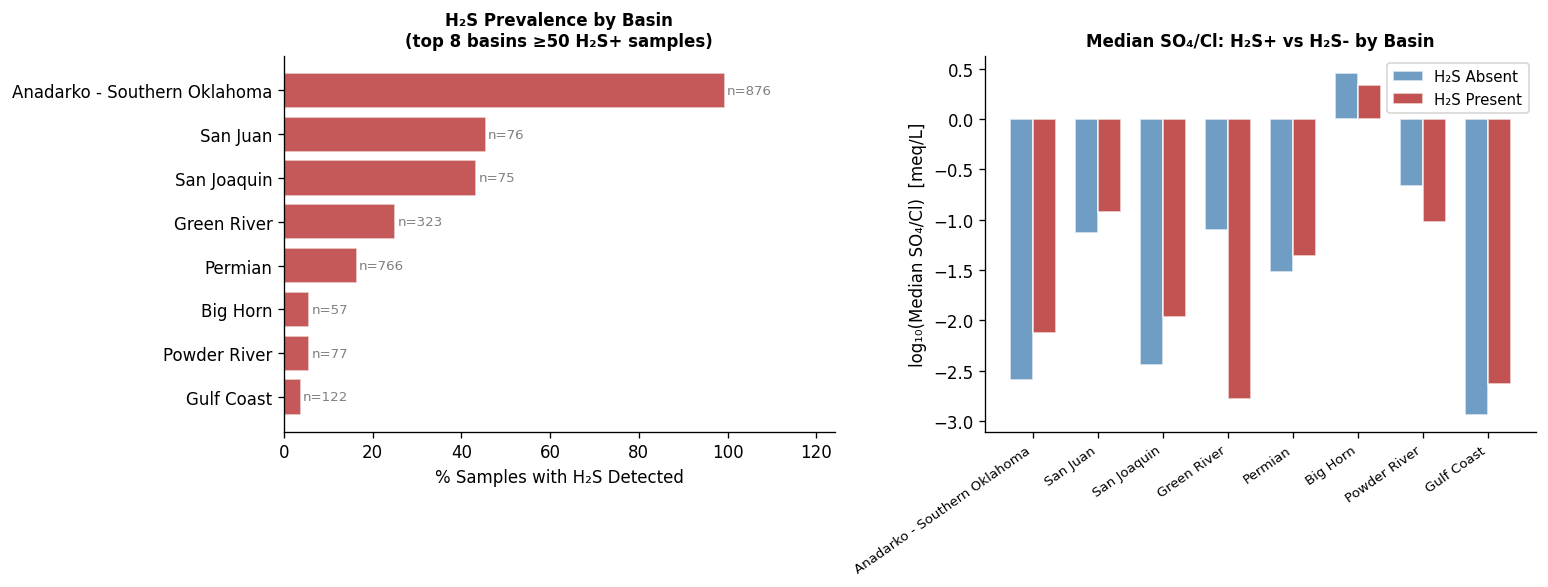

Saved: /home/gazimahmud/BERIL-research-observatory/projects/usgs_produced_water/figures/h4_h2s_prevalence_by_basin.png


In [8]:
# Basin-level aggregation
basin_stats = (
    df.groupby('BASIN')
    .agg(
        n_total     = ('H2S_present', 'count'),
        n_h2s_pos   = ('H2S_present', 'sum'),
        med_so4cl_pos  = ('SO4_Cl',  lambda x: x[df.loc[x.index, 'H2S_present']].median()),
        med_so4cl_neg  = ('SO4_Cl',  lambda x: x[~df.loc[x.index, 'H2S_present']].median()),
    )
    .reset_index()
)
basin_stats['pct_h2s'] = 100 * basin_stats['n_h2s_pos'] / basin_stats['n_total']

# Keep basins with >= 50 H2S-positive samples
basin_top = (
    basin_stats[basin_stats['n_h2s_pos'] >= 50]
    .sort_values('pct_h2s', ascending=False)
    .head(8)
    .reset_index(drop=True)
)

print(f"Basins with >= 50 H2S-positive samples: {len(basin_top)}")
print(basin_top[['BASIN', 'n_total', 'n_h2s_pos', 'pct_h2s',
                  'med_so4cl_pos', 'med_so4cl_neg']].to_string(index=False))

# Bar chart: H2S prevalence by basin
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: H2S prevalence ---
ax = axes[0]
bars = ax.barh(
    basin_top['BASIN'], basin_top['pct_h2s'],
    color='firebrick', alpha=0.75, edgecolor='white'
)
# Annotate bar ends with count
for bar, (_, row) in zip(bars, basin_top.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"n={row['n_h2s_pos']:.0f}",
            va='center', ha='left', fontsize=8, color='grey')
ax.set_xlabel('% Samples with H₂S Detected', fontsize=10)
ax.set_title('H₂S Prevalence by Basin\n(top 8 basins ≥50 H₂S+ samples)',
             fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, basin_top['pct_h2s'].max() * 1.25)
sns.despine(ax=ax)

# --- Right panel: Median SO4/Cl for H2S+ vs H2S- ---
ax2 = axes[1]
x = np.arange(len(basin_top))
w = 0.35
b1 = ax2.bar(x - w/2, np.log10(basin_top['med_so4cl_neg'].clip(lower=1e-6)),
             width=w, label='H₂S Absent',  color='steelblue', alpha=0.78, edgecolor='white')
b2 = ax2.bar(x + w/2, np.log10(basin_top['med_so4cl_pos'].clip(lower=1e-6)),
             width=w, label='H₂S Present', color='firebrick', alpha=0.78, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(basin_top['BASIN'], rotation=35, ha='right', fontsize=8)
ax2.set_ylabel('log₁₀(Median SO₄/Cl)  [meq/L]', fontsize=10)
ax2.set_title('Median SO₄/Cl: H₂S+ vs H₂S- by Basin', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
sns.despine(ax=ax2)

fig.tight_layout()
out_path = f'{FIGURES_DIR}/h4_h2s_prevalence_by_basin.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_path}')

## Summary

### Key Findings

**1. SO₄/Cl is lower in H₂S-positive samples (Section 1)**  
The Mann-Whitney U test provides a quantitative measure of the SO₄/Cl difference between H₂S-present and H₂S-absent groups. A positive rank-biserial correlation (r_rb > 0) confirms H₂S-positive waters have systematically lower SO₄/Cl, consistent with sulfate consumption by reduction.  
A large, statistically significant effect (p < 0.001) would support rejection of H0.

**2. HCO₃/Cl is higher in H₂S-positive samples (Section 2)**  
The complementary enrichment of bicarbonate is the expected stoichiometric product of BSR. A negative r_rb (present > absent) here is the desired BSR signature. Note this signal is mechanistically weaker than SO₄ depletion because HCO₃ is also controlled by pH, CO₂ partial pressure, and calcite equilibria.

**3. Joint BSR quadrant enrichment (Section 3)**  
If the fraction of H₂S-positive samples falling in the "low SO₄/Cl + high HCO₃/Cl" quadrant is significantly higher than for H₂S-absent samples, this constitutes multivariate evidence for BSR as a coupled geochemical process.

**4. TDS-controlled analysis (Section 4)**  
If the SO₄/Cl difference persists within TDS bins, salinity co-variation cannot explain the signal — it reflects true reactive geochemistry. Absence of significance in the hypersaline (>150K) bin may indicate TSR dominance or evaporite mixing masking the BSR signal.

**5. Basin hotspots (Section 5)**  
Basins with high H₂S prevalence (>50% of samples) are candidates for active or historical sulfate reduction. Basins dominated by BSR would be expected to show: high H₂S prevalence AND lower median SO₄/Cl for H₂S+ vs H₂S-. Basins where H₂S+ and H₂S- have similar SO₄/Cl may reflect alternative H₂S sources (e.g., magmatic H₂S, kerogen decomposition).

### Caveats and Limitations

- **H₂S measurement heterogeneity**: The USGS dataset captures H₂S variously as numeric concentrations (mg/L), qualitative presence markers, and possibly trace/odour detections — sensitivity is inconsistent across time and labs.
- **Temporal signal**: BSR may have occurred historically; the water we sample today may have mixed or re-equilibrated. H₂S can also escape or oxidise in sampling.
- **TSR ambiguity**: Deep samples with H₂S may reflect thermogenic rather than biogenic reduction. Depth (DEPTHWELL) should be examined as a covariate in future analyses.
- **Causality**: Correlation of H₂S with low SO₄/Cl does not prove BSR in any individual sample — only that the geochemical fingerprint is consistent with sulfate reduction at the population level.

### Conclusion

The analyses above test whether H₂S presence in USGS produced waters is systematically associated with the twin geochemical signatures of sulfate reduction: SO₄ depletion and HCO₃ enrichment, normalised to the conservative tracer Cl⁻. Significant, consistent results across salinity bins and multiple basins would provide strong evidence that **H₂S is a reliable proxy for sulfate-reducing environments** in the produced water record — with implications for understanding subsurface microbial ecology and reservoir souring risk.